In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph # framework that helps you design and manage the flow of tasks in your application using a graph structure
from functools import reduce

In [13]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict): # Our state schema
    name     : str
    age      : int
    skills  : List[str]
    message  : str


def first_node(state: AgentState) -> AgentState:
    """Simple node one on the state"""
    state["message"] = f"Hi! {state["name"]}, nice to meet you! Welcome to the system. "
    return state

def second_node(state: AgentState) -> AgentState:
    """Simple node two on the state"""
    state["message"] = state["message"] + f"You are {state["age"]} years old. "
    return state

def third_node(state: AgentState) -> AgentState:
    """Simple node three on the state"""
    state["message"] = state["message"] + f"Your skills are {", ".join(state["skills"])}."
    return state

In [14]:
graph = StateGraph(AgentState)

graph.add_node("first", first_node)
graph.add_node("second", second_node)
graph.add_node("third", third_node)

graph.set_entry_point("first")
graph.add_edge("first", "second")
graph.add_edge("second", "third")
graph.set_finish_point("third")

app = graph.compile()

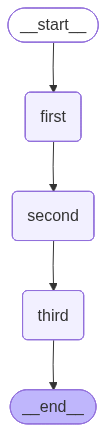

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
result = app.invoke({"name": "Bob", "age": 31, "skills" : ["Python", "Langgraph", "and", "Agents"]})
result["message"]

'Hi! Bob, nice to meet you! Welcome to the system. You are 31 years old. Your skills are Python, Langgraph, and, Agents.'